In [1]:
import pandas as pd
import numpy as np

In [2]:
raw_trades = pd.read_csv('/Users/mryiadom/aws-de-portfolio/data/raw_trades.csv')

In [3]:
raw_trades.head()

,trade_id,instrument_id,ticker,sector,trade_date,price,volume,venue_code,side
0,1001,1,AAPL,Technology,2026-01-15,NaN,2500.0,XNAS,SELL
1,1002,1,AAPL,Technology,2026-01-08,NaN,1000.0,XNAS,BUY
2,1003,1,AAPL,Technology,2026-02-09,219.86,7500.0,XNAS,BUY
3,1004,1,AAPL,Technology,2026-02-16,215.86,2000.0,XNAS,SELL
4,1005,1,AAPL,Technology,2026-03-13,209.18,1500.0,XNAS,SELL


In [4]:
raw_trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trade_id       56 non-null     int64  
 1   instrument_id  56 non-null     int64  
 2   ticker         56 non-null     str    
 3   sector         56 non-null     str    
 4   trade_date     56 non-null     str    
 5   price          50 non-null     float64
 6   volume         53 non-null     float64
 7   venue_code     56 non-null     str    
 8   side           56 non-null     str    
dtypes: float64(2), int64(2), str(5)
memory usage: 4.1 KB


In [5]:
raw_trades.shape

(56, 9)

In [6]:
raw_trades.dtypes

trade_id           int64
instrument_id      int64
ticker               str
sector               str
trade_date           str
price            float64
volume           float64
venue_code           str
side                 str
dtype: object

In [7]:
raw_trades['volume'] = raw_trades['volume'].astype('Int64')
raw_trades['trade_date'] = pd.to_datetime(raw_trades['trade_date'])

In [8]:
raw_trades.dtypes

trade_id                  int64
instrument_id             int64
ticker                      str
sector                      str
trade_date       datetime64[us]
price                   float64
volume                    Int64
venue_code                  str
side                        str
dtype: object

In [9]:
raw_trades.isna().sum()

trade_id         0
instrument_id    0
ticker           0
sector           0
trade_date       0
price            6
volume           3
venue_code       0
side             0
dtype: int64

In [10]:
raw_trades.set_index('trade_date', inplace=True)
raw_trades.sort_index(ascending=True, inplace=True)

In [11]:
raw_trades.head()

,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side
trade_date,,,,,,,,
2026-01-03,1044,5,JNJ,Healthcare,160.04,1000,XNYS,SELL
2026-01-03,1045,5,JNJ,Healthcare,152.56,7500,XNYS,SELL
2026-01-07,1012,2,MSFT,Technology,438.92,1500,XNAS,SELL
2026-01-08,1002,1,AAPL,Technology,NaN,1000,XNAS,BUY
2026-01-11,1013,2,MSFT,Technology,447.60,7500,XNAS,BUY


In [12]:
raw_trades['trade_month'] = raw_trades.index.month
raw_trades['trade_year'] = raw_trades.index.year

In [13]:
raw_trades.head()

,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side,trade_month,trade_year
trade_date,,,,,,,,,,
2026-01-03,1044,5,JNJ,Healthcare,160.04,1000,XNYS,SELL,1,2026
2026-01-03,1045,5,JNJ,Healthcare,152.56,7500,XNYS,SELL,1,2026
2026-01-07,1012,2,MSFT,Technology,438.92,1500,XNAS,SELL,1,2026
2026-01-08,1002,1,AAPL,Technology,NaN,1000,XNAS,BUY,1,2026
2026-01-11,1013,2,MSFT,Technology,447.60,7500,XNAS,BUY,1,2026


In [14]:
raw_trades.query('trade_month == 1')

,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side,trade_month,trade_year
trade_date,,,,,,,,,,
2026-01-03,1044,5,JNJ,Healthcare,160.04,1000,XNYS,SELL,1,2026
2026-01-03,1045,5,JNJ,Healthcare,152.56,7500,XNYS,SELL,1,2026
2026-01-07,1012,2,MSFT,Technology,438.92,1500,XNAS,SELL,1,2026
2026-01-08,1002,1,AAPL,Technology,NaN,1000,XNAS,BUY,1,2026
2026-01-11,1013,2,MSFT,Technology,447.60,7500,XNAS,BUY,1,2026
2026-01-13,1023,3,JPM,Financials,201.75,750,XNYS,BUY,1,2026
2026-01-13,1023,3,JPM,Financials,201.75,750,XNYS,BUY,1,2026
2026-01-15,1001,1,AAPL,Technology,NaN,2500,XNAS,SELL,1,2026
2026-01-17,1024,3,JPM,Financials,206.01,750,XNYS,SELL,1,2026


In [15]:
raw_trades[raw_trades['trade_month'] == 1]

,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side,trade_month,trade_year
trade_date,,,,,,,,,,
2026-01-03,1044,5,JNJ,Healthcare,160.04,1000,XNYS,SELL,1,2026
2026-01-03,1045,5,JNJ,Healthcare,152.56,7500,XNYS,SELL,1,2026
2026-01-07,1012,2,MSFT,Technology,438.92,1500,XNAS,SELL,1,2026
2026-01-08,1002,1,AAPL,Technology,NaN,1000,XNAS,BUY,1,2026
2026-01-11,1013,2,MSFT,Technology,447.60,7500,XNAS,BUY,1,2026
2026-01-13,1023,3,JPM,Financials,201.75,750,XNYS,BUY,1,2026
2026-01-13,1023,3,JPM,Financials,201.75,750,XNYS,BUY,1,2026
2026-01-15,1001,1,AAPL,Technology,NaN,2500,XNAS,SELL,1,2026
2026-01-17,1024,3,JPM,Financials,206.01,750,XNYS,SELL,1,2026


In [16]:
raw_trades.loc[raw_trades['trade_month'] == 1, ["ticker", "price"]]

,ticker,price
trade_date,,
2026-01-03,JNJ,160.04
2026-01-03,JNJ,152.56
2026-01-07,MSFT,438.92
2026-01-08,AAPL,NaN
2026-01-11,MSFT,447.60
2026-01-13,JPM,201.75
2026-01-13,JPM,201.75
2026-01-15,AAPL,NaN
2026-01-17,JPM,206.01


In [17]:
raw_trades.isna().sum()

trade_id         0
instrument_id    0
ticker           0
sector           0
price            6
volume           3
venue_code       0
side             0
trade_month      0
trade_year       0
dtype: int64

In [18]:
raw_trades.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 56 entries, 2026-01-03 to 2026-06-25
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trade_id       56 non-null     int64  
 1   instrument_id  56 non-null     int64  
 2   ticker         56 non-null     str    
 3   sector         56 non-null     str    
 4   price          50 non-null     float64
 5   volume         53 non-null     Int64  
 6   venue_code     56 non-null     str    
 7   side           56 non-null     str    
 8   trade_month    56 non-null     int32  
 9   trade_year     56 non-null     int32  
dtypes: Int64(1), float64(1), int32(2), int64(2), str(4)
memory usage: 4.4 KB


In [19]:
raw_trades.drop_duplicates(inplace=True)

In [20]:
raw_trades.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 54 entries, 2026-01-03 to 2026-06-25
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   trade_id       54 non-null     int64  
 1   instrument_id  54 non-null     int64  
 2   ticker         54 non-null     str    
 3   sector         54 non-null     str    
 4   price          48 non-null     float64
 5   volume         51 non-null     Int64  
 6   venue_code     54 non-null     str    
 7   side           54 non-null     str    
 8   trade_month    54 non-null     int32  
 9   trade_year     54 non-null     int32  
dtypes: Int64(1), float64(1), int32(2), int64(2), str(4)
memory usage: 4.3 KB


In [21]:
raw_trades['price'] = raw_trades.groupby("ticker")['price'].transform(lambda x: x.fillna(x.mean()))
raw_trades['volume'] = raw_trades.groupby("ticker")['volume'].transform(lambda x: x.fillna(round(x.mean())))

In [22]:
raw_trades

,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side,trade_month,trade_year
trade_date,,,,,,,,,,
2026-01-03,1044,5,JNJ,Healthcare,160.040000,1000,XNYS,SELL,1,2026
2026-01-03,1045,5,JNJ,Healthcare,152.560000,7500,XNYS,SELL,1,2026
2026-01-07,1012,2,MSFT,Technology,438.920000,1500,XNAS,SELL,1,2026
2026-01-08,1002,1,AAPL,Technology,219.788889,1000,XNAS,BUY,1,2026
2026-01-11,1013,2,MSFT,Technology,447.600000,7500,XNAS,BUY,1,2026
2026-01-13,1023,3,JPM,Financials,201.750000,750,XNYS,BUY,1,2026
2026-01-15,1001,1,AAPL,Technology,219.788889,2500,XNAS,SELL,1,2026
2026-01-17,1024,3,JPM,Financials,206.010000,750,XNYS,SELL,1,2026
2026-01-27,1034,4,XOM,Energy,124.220000,1000,XNYS,BUY,1,2026


In [23]:
raw_trades['price_global_mean'] = raw_trades['price'].mean()
raw_trades.head(10)

,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side,trade_month,trade_year,price_global_mean
trade_date,,,,,,,,,,,
2026-01-03,1044,5,JNJ,Healthcare,160.040000,1000,XNYS,SELL,1,2026,237.633496
2026-01-03,1045,5,JNJ,Healthcare,152.560000,7500,XNYS,SELL,1,2026,237.633496
2026-01-07,1012,2,MSFT,Technology,438.920000,1500,XNAS,SELL,1,2026,237.633496
2026-01-08,1002,1,AAPL,Technology,219.788889,1000,XNAS,BUY,1,2026,237.633496
2026-01-11,1013,2,MSFT,Technology,447.600000,7500,XNAS,BUY,1,2026,237.633496
2026-01-13,1023,3,JPM,Financials,201.750000,750,XNYS,BUY,1,2026,237.633496
2026-01-15,1001,1,AAPL,Technology,219.788889,2500,XNAS,SELL,1,2026,237.633496
2026-01-17,1024,3,JPM,Financials,206.010000,750,XNYS,SELL,1,2026,237.633496
2026-01-27,1034,4,XOM,Energy,124.220000,1000,XNYS,BUY,1,2026,237.633496


In [24]:
raw_trades['price_global_mean_difference'] = raw_trades['price_global_mean'] - raw_trades.query('ticker == "AAPL"')['price']
aapl_mean = raw_trades[raw_trades['ticker'] == 'AAPL']['price'].mean()
global_mean = raw_trades['price'].mean()
gap = global_mean - aapl_mean

In [25]:
print(gap)

17.84460699588473


## Wednesday — reshaping: groupby + agg, pivot_table, merge

In [26]:
raw_trades.groupby('ticker').agg({'volume': 'sum', 'price': 'mean'})

,volume,price
ticker,,
AAPL,28875,219.788889
JNJ,54250,153.438000
JPM,14850,213.213000
MSFT,61050,473.051818
XOM,17750,117.780000


In [27]:
pivot = pd.pivot_table(raw_trades, values='volume', index='ticker', columns='trade_month', aggfunc='sum')
print(pivot.shape)
pivot

(5, 6)


trade_month,1,2,3,4,5,6
ticker,,,,,,
AAPL,3500,9500,4000,7500,3625,750
JNJ,8500,14000,1750,12500,7500,10000
JPM,1500,1350,6000,2250,2500,1250
MSFT,9000,4000,2000,9000,19500,17550
XOM,1000,7500,4000,1250,2500,1500


In [28]:
# Merge trades onto a separate instruments frame to attach sector, and confirm the row
# count doesn't change -- if it grew, the join key (ticker) would not be unique in instruments.
instruments = raw_trades[['ticker', 'sector']].drop_duplicates().reset_index(drop=True)
trades_no_sector = raw_trades.drop(columns='sector').reset_index()
merged = trades_no_sector.merge(instruments, on='ticker', how='left')
print('rows before merge:', len(raw_trades), '| rows after merge:', len(merged))
merged.head()

rows before merge: 54 | rows after merge: 54


,trade_date,trade_id,instrument_id,ticker,price,volume,venue_code,side,trade_month,trade_year,price_global_mean,price_global_mean_difference,sector
0,2026-01-03,1044,5,JNJ,160.040000,1000,XNYS,SELL,1,2026,237.633496,NaN,Healthcare
1,2026-01-03,1045,5,JNJ,152.560000,7500,XNYS,SELL,1,2026,237.633496,NaN,Healthcare
2,2026-01-07,1012,2,MSFT,438.920000,1500,XNAS,SELL,1,2026,237.633496,NaN,Technology
3,2026-01-08,1002,1,AAPL,219.788889,1000,XNAS,BUY,1,2026,237.633496,17.844607,Technology
4,2026-01-11,1013,2,MSFT,447.600000,7500,XNAS,BUY,1,2026,237.633496,NaN,Technology


## Thursday — dates: resample, rolling windows, groupby().transform()

In [29]:
raw_trades['volume'].resample('ME').sum()

trade_date
2026-01-31    23500
2026-02-28    36350
2026-03-31    17750
2026-04-30    32500
2026-05-31    35625
2026-06-30    31050
Freq: ME, Name: volume, dtype: Int64

In [30]:
# 3-trade rolling average price, computed separately per instrument via transform()
raw_trades['rolling_avg_price'] = raw_trades.groupby('ticker')['price'].transform(lambda x: x.rolling(3).mean())
raw_trades[['ticker', 'price', 'rolling_avg_price']].head(10)

,ticker,price,rolling_avg_price
trade_date,,,
2026-01-03,JNJ,160.040000,NaN
2026-01-03,JNJ,152.560000,NaN
2026-01-07,MSFT,438.920000,NaN
2026-01-08,AAPL,219.788889,NaN
2026-01-11,MSFT,447.600000,NaN
2026-01-13,JPM,201.750000,NaN
2026-01-15,AAPL,219.788889,NaN
2026-01-17,JPM,206.010000,NaN
2026-01-27,XOM,124.220000,NaN


In [31]:
# Prove the rolling window was computed per-group, not over the whole DataFrame:
# the first 2 rows of EVERY ticker should be null, not just the first 2 rows overall.
first_two_null_per_ticker = raw_trades.groupby('ticker')['rolling_avg_price'].apply(lambda x: x.iloc[:2].isna().all())
first_two_null_per_ticker

ticker
AAPL    True
JNJ     True
JPM     True
MSFT    True
XOM     True
Name: rolling_avg_price, dtype: bool

## Friday — apply vs transform vs agg; boolean indexing; first charts

In [32]:
# Same aggregation (mean price per ticker), three ways -- compare what each returns.
via_agg = raw_trades.groupby('ticker')['price'].agg('mean')
via_apply = raw_trades.groupby('ticker')['price'].apply(lambda x: x.mean())
via_transform = raw_trades.groupby('ticker')['price'].transform(lambda x: x.mean())

print('agg shape:', via_agg.shape, '-- one row per group, collapsed')
print('apply shape:', via_apply.shape, '-- one row per group, collapsed (like agg here)')
print('transform shape:', via_transform.shape, '-- one row per ORIGINAL row, broadcast back, not collapsed')

agg shape: (5,) -- one row per group, collapsed
apply shape: (5,) -- one row per group, collapsed (like agg here)
transform shape: (54,) -- one row per ORIGINAL row, broadcast back, not collapsed


In [33]:
technology_trades = raw_trades[raw_trades['sector'].isin(['Technology'])]
print('Technology rows:', len(technology_trades))
technology_trades.head()

Technology rows: 22


,trade_id,instrument_id,ticker,sector,price,volume,venue_code,side,trade_month,trade_year,price_global_mean,price_global_mean_difference,rolling_avg_price
trade_date,,,,,,,,,,,,,
2026-01-07,1012,2,MSFT,Technology,438.920000,1500,XNAS,SELL,1,2026,237.633496,NaN,NaN
2026-01-08,1002,1,AAPL,Technology,219.788889,1000,XNAS,BUY,1,2026,237.633496,17.844607,NaN
2026-01-11,1013,2,MSFT,Technology,447.600000,7500,XNAS,BUY,1,2026,237.633496,NaN,NaN
2026-01-15,1001,1,AAPL,Technology,219.788889,2500,XNAS,SELL,1,2026,237.633496,17.844607,NaN
2026-02-02,1014,2,MSFT,Technology,464.030000,2500,XNAS,BUY,2,2026,237.633496,NaN,450.183333


Matplotlib is building the font cache; this may take a moment.


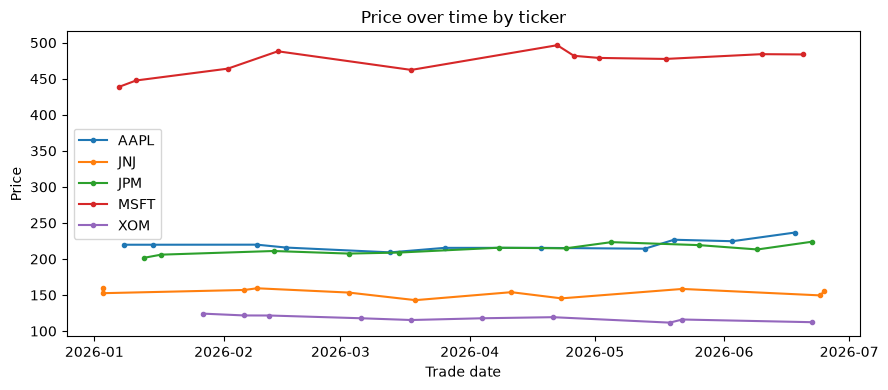

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for ticker, group in raw_trades.groupby('ticker'):
    ax.plot(group.index, group['price'], marker='o', markersize=3, label=ticker)
ax.set_title('Price over time by ticker')
ax.set_xlabel('Trade date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

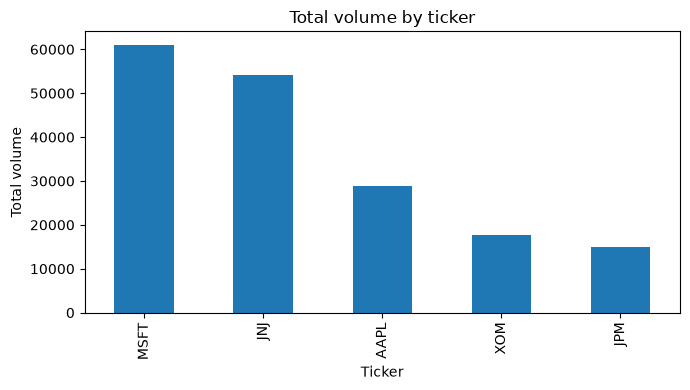

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
raw_trades.groupby('ticker')['volume'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax)
ax.set_title('Total volume by ticker')
ax.set_xlabel('Ticker')
ax.set_ylabel('Total volume')
plt.tight_layout()
plt.show()

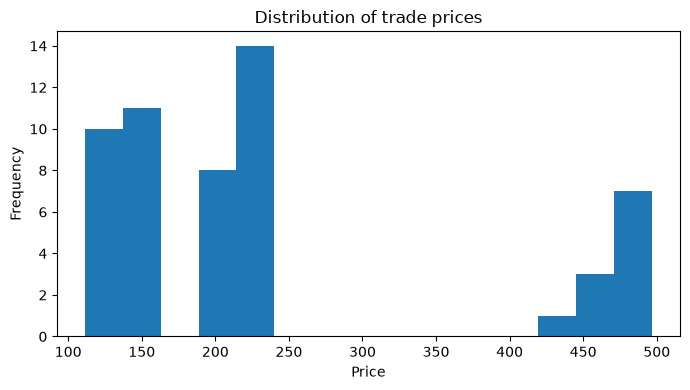

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
raw_trades['price'].plot(kind='hist', bins=15, ax=ax)
ax.set_title('Distribution of trade prices')
ax.set_xlabel('Price')
plt.tight_layout()
plt.show()